In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
word_embeddings = {
    "cat":[0.1, 0.2, 0.3],
    "dog":[0.2, 0.1, 0.4],
    "mouse":[0.3, 0.4, 0.1],
    "car":[0.5, 0.6, 0.7],
    "bus":[0.6, 0.5, 0.8],
    "bicycle":[0.7, 0.8, 0.6]
}

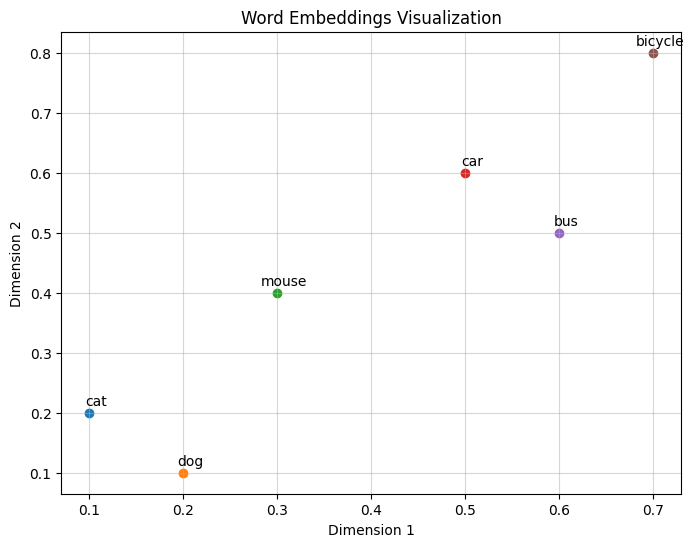

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
for word, embedding in word_embeddings.items():
    ax.scatter(embedding[0], embedding[1], label=word)
    ax.annotate(word, (embedding[0], embedding[1]), textcoords="offset points", xytext=(5,5), ha='center')
    textcoords="offset points"

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Word Embeddings Visualization")
ax.grid(alpha=0.5)



In [4]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2)

In [5]:
cat_vector =[0.1, 0.2, 0.3]
dog_vector =[0.2, 0.1, 0.4]
car_vector =[0.5, 0.6, 0.7]

similarity_cat_dog = cosine_similarity(cat_vector, dog_vector)
similarity_cat_car = cosine_similarity(cat_vector, car_vector)
print(f"Cosine Similarity between 'cat' and 'dog': {similarity_cat_dog:.4f}")
print(f"Cosine Similarity between 'cat' and 'car': {similarity_cat_car:.4f}")



Cosine Similarity between 'cat' and 'dog': 0.9331
Cosine Similarity between 'cat' and 'car': 0.9683


### Creating Your First Embeddings in Hugging Face


In [8]:
pip install langchain-huggingface

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 40.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [tokenizers]
   ---------------------------------------- 0/2 [tokenizers]
   -------------------- ------------------- 1/2 [langchain-huggingface]
   -------------------- ------------------- 1/2 [langchain-huggingface]
   ---------------------------------------- 2/2 [langchain-huggingface]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install sentence-transformers

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 10.8/10.8 MB 61.2 MB/s  0:00:00
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)

   ---------------------------------------- 0/4 [safetensors]
  Attempting uninstall: tokenizers
   ---------------------------------------- 0/4 [safetensors]
    Found existing installation: tokenizers 0.23.1
   ---------------------------------------- 0/4 [safetensors]
    Uninstalling tokenizers-0.23.1:
   ---------------------------------------- 0/4 [safetensors]
      Successfully uninstalled tokenizers-0.23.1
   ----


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

embedding_model

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [19]:
text = "The cat is on the roof."
embedding = embedding_model.embed_query(text)

print(f"Embedding for the text: {embedding}")
print(f"Embedding dimension: {len(embedding)}")



Embedding for the text: [0.09014216810464859, 0.07564277946949005, 0.020247461274266243, 0.012722763232886791, -0.04801318794488907, -0.012389593757689, 0.014910424128174782, 0.020820697769522667, -0.0007705169264227152, 0.025479156523942947, -0.038932666182518005, 0.05134262144565582, 0.009062432684004307, -0.00828572828322649, -0.021775677800178528, 0.00042899345862679183, -0.06776208430528641, -0.012746322900056839, 0.044649623334407806, 0.041595928370952606, -0.0027069237548857927, -0.03153901547193527, 0.019125329330563545, -0.034822139889001846, -0.043293505907058716, 0.0433015301823616, -0.06230577826499939, -0.031219149008393288, -0.0025235542561858892, -0.016854336485266685, -0.016138607636094093, -0.0036168580409139395, -0.07031159102916718, 0.06256606429815292, -0.014947699382901192, -0.05734643340110779, -0.00033931375946849585, -0.041513603180646896, -0.017820728942751884, 0.0860838070511818, 0.03254354000091553, -0.0035632308572530746, -0.08422219753265381, -0.02980217337

In [34]:
sentences = [
    "The cat is on the roof.",
    "The dog is in the yard.",
    "The car is parked outside."
    "The bus is at the station.",
    "The bicycle is in the garage.",
    "The mouse is under the table."
]
embeddings = embedding_model.embed_documents(sentences)

print(f"Embedding for the text: {embeddings[4]}")
print(f"Embedding dimension: {len(embeddings[4])}")
print(embeddings[2])
print(f"Embedding dimension: {len(embeddings[2])}")

Embedding for the text: [-0.008508994244039059, -0.004526303615421057, -0.023327721282839775, -0.04983368143439293, -0.004876881372183561, 0.030490774661302567, 0.08922268450260162, 0.01926669478416443, 0.014000737108290195, 0.07487344741821289, 0.05264405161142349, 0.04522143304347992, -0.025735724717378616, 0.03167562559247017, -0.026289215311408043, -0.04843069612979889, 0.0077484725043177605, -0.051497384905815125, -0.014772883616387844, 0.025773510336875916, 0.02227284014225006, -0.06742515414953232, 0.039924461394548416, -0.04084266722202301, -0.016763873398303986, -0.0005492196069099009, 0.040197476744651794, -0.01460490096360445, -0.06266538798809052, -0.03612695261836052, -0.032993383705616, -0.013930009678006172, -0.05112601816654205, -0.010420253500342369, -0.06889495998620987, -0.08548172563314438, -0.037423864006996155, 0.0017527244053781033, 0.01261775754392147, -0.007908950559794903, -0.06122659519314766, -0.07678079605102539, 0.040701285004615784, 0.07093436270952225, -

In [28]:

embeddings = embedding_model.embed_documents(sentences)

print(f"Embedding for the text: {embeddings[3]}")
print(f"Embedding dimension: {len(embeddings[3])}")



Embedding for the text: [-0.006279725581407547, 0.0782567486166954, -0.0501847118139267, -0.01872146688401699, -0.03870321065187454, 0.05779515206813812, -0.029642073437571526, 0.05765099823474884, 0.008791170082986355, -0.006125267129391432, 0.04290102794766426, -0.05206327512860298, 0.07232454419136047, -0.06195259094238281, 0.08229880779981613, 0.08989685028791428, 0.02131093479692936, 0.02034422568976879, -0.025835633277893066, 0.013870205730199814, 0.04529360309243202, 0.03724159300327301, -0.02436501905322075, 0.0019507865654304624, 0.023797105997800827, 0.059050049632787704, -0.0596323199570179, 0.009932979010045528, 0.007678030990064144, -0.014841627329587936, -0.03134923428297043, 0.10178683698177338, 0.05820310115814209, -0.022624274715781212, 0.0970163345336914, 0.01935764215886593, 0.009072663262486458, -0.061711400747299194, -0.004315072204917669, -0.09684332460165024, -0.012981673702597618, 0.022312790155410767, -0.022772546857595444, -0.10112465918064117, 0.0582764782011

In [35]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

